In [ ]:
import h5py
import numpy as np

f = h5py.File("/Volumes/Crucial X10/210/xgaze_448/train/subject0000.h5", "r")
print("Keys:", list(f.keys()))
print("Num samples:", f["face_patch"].shape)
print("Gaze shape:", f["face_gaze"].shape)

gaze = f["face_gaze"][:]
pitch = gaze[:, 0]  # vertical 

print(f"\nPitch range: {np.degrees(pitch.min()):.1f}° to {np.degrees(pitch.max()):.1f}°")
print(f"Samples with pitch < -10°: {(pitch < np.radians(-10)).sum()}")
print(f"Samples with pitch < -20°: {(pitch < np.radians(-20)).sum()}")

Keys: ['cam_index', 'face_gaze', 'face_head_pose', 'face_mat_norm', 'face_patch', 'frame_index']
Num samples: (10098, 448, 448, 3)
Gaze shape: (10098, 2)

Pitch range: -73.0° to 69.2°
Samples with pitch < -10°: 4689
Samples with pitch < -20°: 3513


In [3]:
print(f"Samples with pitch > 10°: {(pitch > np.radians(10)).sum()}")
print(f"Samples with pitch > 20°: {(pitch > np.radians(20)).sum()}")

Samples with pitch > 10°: 3274
Samples with pitch > 20°: 2246


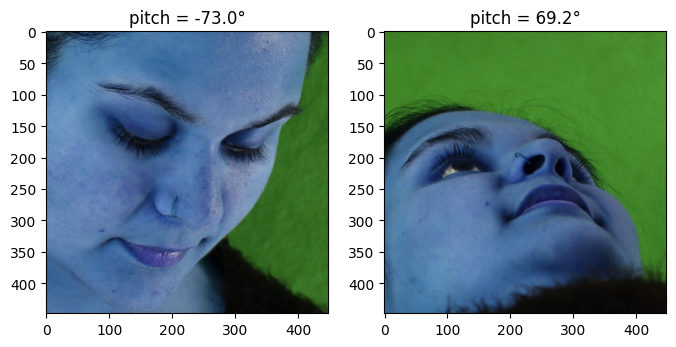

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

# Show a sample with very negative pitch
idx_neg = np.argmin(pitch)
# Show a sample with very positive pitch  
idx_pos = np.argmax(pitch)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(f["face_patch"][idx_neg])
axes[0].set_title(f"pitch = {np.degrees(pitch[idx_neg]):.1f}°")
axes[1].imshow(f["face_patch"][idx_pos])
axes[1].set_title(f"pitch = {np.degrees(pitch[idx_pos]):.1f}°")
plt.show()

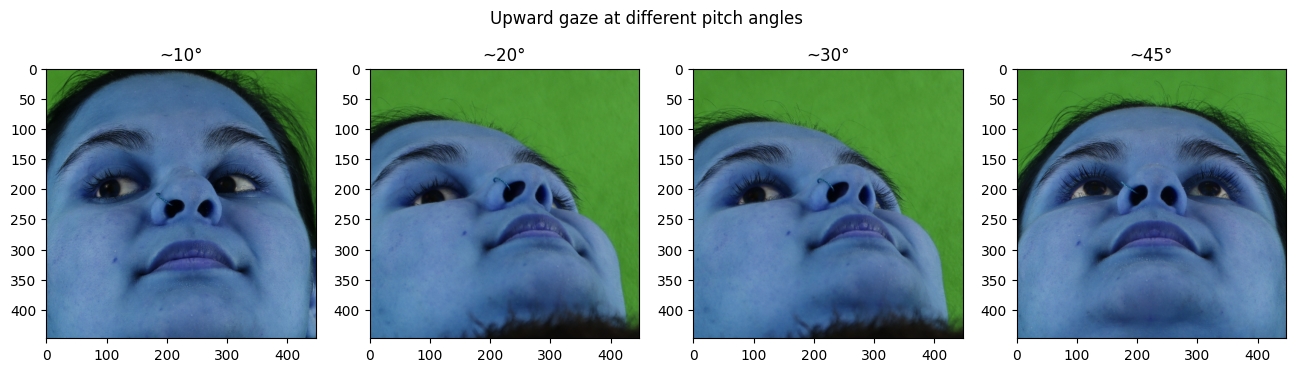

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, deg in zip(axes, [10, 20, 30, 45]):
    mask = (pitch > np.radians(deg)) & (pitch < np.radians(deg + 5))
    idx = np.where(mask)[0][0]
    ax.imshow(f["face_patch"][idx])
    ax.set_title(f"~{deg}°")
plt.suptitle("Upward gaze at different pitch angles")
plt.show()

Up gaze + neutral head: 347 samples


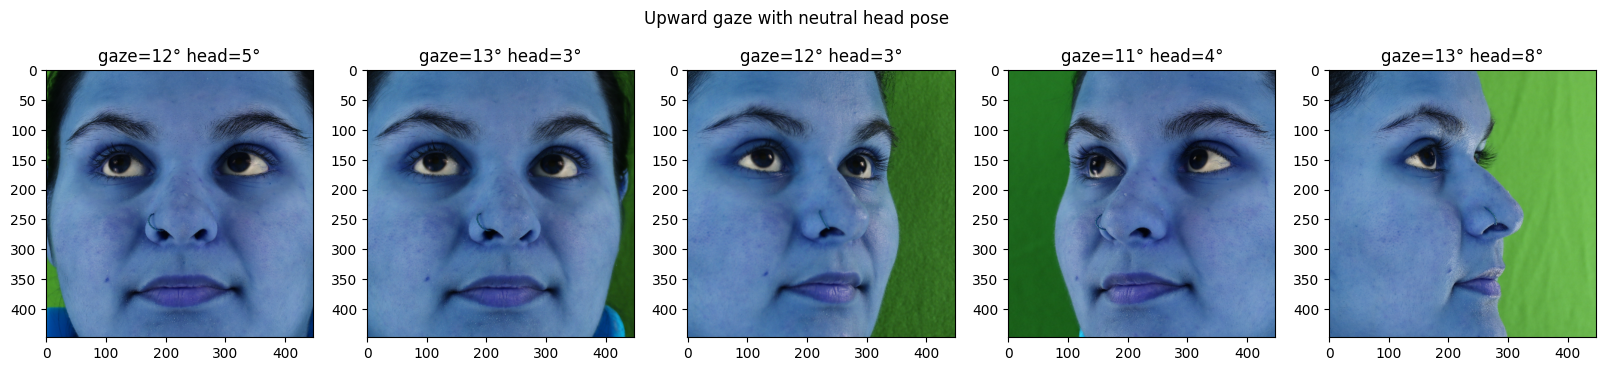

In [6]:
head_pose = f["face_head_pose"][:]
head_pitch = head_pose[:, 0]

# Upward gaze + relatively neutral head
mask = (pitch > np.radians(10)) & (np.abs(head_pitch) < np.radians(15))
idxs = np.where(mask)[0]
print(f"Up gaze + neutral head: {len(idxs)} samples")

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, idx in zip(axes, idxs[:5]):
    ax.imshow(f["face_patch"][idx])
    ax.set_title(f"gaze={np.degrees(pitch[idx]):.0f}° head={np.degrees(head_pitch[idx]):.0f}°")
plt.suptitle("Upward gaze with neutral head pose")
plt.show()

In [7]:
head_yaw = head_pose[:, 1]

mask = (
    (pitch > np.radians(10)) & 
    (np.abs(head_pitch) < np.radians(15)) & 
    (np.abs(head_yaw) < np.radians(20))
)
idxs = np.where(mask)[0]
print(f"Up gaze + neutral head + frontal: {len(idxs)} samples")

Up gaze + neutral head + frontal: 141 samples
